In [1]:
import os

from denovo_utils.data import Run
from denovo_utils.parsers import DenovoEngineConverter
from denovo_utils.io.read import load_psmlist

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from denovo_utils.analysis.metrics import load_seq_score_dicts
from denovo_utils.analysis.metrics import get_match_score_table, get_prc_curve

from psm_utils import Peptidoform
from tqdm import tqdm
from peak_pack.utils import calculate_ppm

from denovo_utils.analysis.metrics import (
    get_refinement_error_tables,
    plot_refinement_error_table,
    plot_precision_recall_refinement
)

import pandas as pd

from pathlib import Path

from denovo_utils.io.read import read_partitions_features, read_partitions_psmlist
from denovo_utils.io.save import save_psmlist

from glob import glob
import pickle
import numpy as np
from itertools import chain

2026-09-08 15:09:48.794369: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modification already exists in ModificationsDB. Skipping.


In [2]:
from figsave import autosave
autosave("figures", formats=("svg", "pdf"))

PosixPath('figures')

In [3]:
class Selector:
    @staticmethod
    def get_spectra_from_model(run, denovo_models, include_gold_standard=False):
        spectra = {}
        for spectrum_id, spectrum in run.spectra.items():
            psms = []
            common = True
            for denovo_name in denovo_models:
                psm = spectrum.get_psms_by_engine(engine_name=denovo_name)
                if len(psm) == 0:
                    common = False
                    break
                psms += psm
            if common:
                if include_gold_standard:
                    psms += spectrum.psm_gold_standard
                spectra[spectrum_id] = spectrum
        
        new_run = Run(run.run_id)
        new_run.spectra = spectra
        return new_run

def has_good_eval(psm_candidate, good_labels=['match'], match_type_from_metadata=False):
    if match_type_from_metadata:
        return psm_candidate.metadata['match_type'] in good_labels

    for evaluation in psm_candidate.evaluations.values():
        if evaluation['score_ms2rescore'].error_type in good_labels:
            return True
    return False

def get_match_score_table(
        runs,
        engine,
        score_metadata,
        match_type_from_metadata=True,
        good_labels=['match'],
        eval_score_metadata="score_ms2rescore",
        refiner=None,
        return_table=False
    ):

    pr_tables = []

    for run in runs.values():

        pr_table = {
            "spectrum_id": [],
            "score": [],
            "match": []
        }
        missing = 0

        for spectrum in run.spectra.values():
            
            psm = spectrum.get_psms_by_engine(engine)[0]

            if refiner is not None:
                if refiner not in psm.refinement.keys():
                    missing+=1
                    continue
                if psm.refinement[refiner][1]:
                    pr_table["match"].append(has_good_eval(psm, good_labels, match_type_from_metadata))
                    pr_table["score"].append(psm.scores.get_score(score_metadata))
                else:
                    psm_refinement = psm.refinement[refiner][0]
                    pr_table["match"].append(has_good_eval(psm_refinement, good_labels, match_type_from_metadata))
                    pr_table["score"].append(psm_refinement.scores.get_score(score_metadata))
                pr_table["spectrum_id"].append(spectrum.spectrum_id)

            else:
                pr_table["match"].append(has_good_eval(psm, good_labels, match_type_from_metadata))
                pr_table["score"].append(psm.scores.get_score(score_metadata))
                pr_table["spectrum_id"].append(spectrum.spectrum_id)
        pr_table = pd.DataFrame(pr_table)
        pr_tables.append(pr_table)

    pr_table = pd.concat(pr_tables, ignore_index=True)

    if return_table:
        return pr_table

    return precision_recall_curve(
        pr_table.match.tolist(),
        pr_table.score.tolist()), missing

def get_match_score_tables(runs, denovo_names, good_labels=['match'], match_type_from_metadata=True):

    tables_by_run = {}
    for filename, run in runs.items():

        tables = {}
        for denovo_name in denovo_names:
            run_denovo = Selector.get_spectra_from_model(run=run, denovo_models=[denovo_name])
            t = get_match_score_table(
                {filename: run_denovo},
                engine=denovo_name,
                score_metadata=denovo_name,
                good_labels=good_labels,
                eval_score_metadata='score_ms2rescore',
                refiner=None,
                return_table=True,
                match_type_from_metadata=match_type_from_metadata
            )
            tables[denovo_name] = t

        tables_by_run[filename] = tables
    
    pr_tables = {denovo_name: [] for denovo_name in denovo_names}
    for filename, tables in tables_by_run.items():
        for denovo_name, table in tables.items():
            pr_tables[denovo_name].append(table)
    
    pr_tables = {denovo_name: pd.concat(tables, ignore_index=True) for denovo_name, tables in pr_tables.items()}
    return pr_tables

def calculate_prc(
        n_correct,
        n_selected,
        n_predicted
):
    c = n_correct
    ci = n_selected
    u = n_predicted - ci

    # precision
    precision = c/ci

    # recall (This is an alternative definition and the line will stop at x=y)
    recall = c/n_predicted

    # coverage
    coverage = ci/n_predicted

    return precision, recall, coverage


def get_prc_curve(t, n_predicted = None):
    prs = []
    recs = []
    covs = []

    t = t.sort_values('score', ascending=False).reset_index(drop=True)

    if n_predicted is None:
        n_predicted = len(t)

    for coverage in tqdm(np.linspace(0,1,200)):
        if coverage == 0:
            continue
        n_samples = coverage * len(t)
        samples_evaluated = t[t.index<n_samples]
        
        pr, rec, cov = calculate_prc(
            n_correct=len(samples_evaluated[samples_evaluated.match]),
            n_selected=len(samples_evaluated),
            n_predicted=n_predicted,
        )
        prs.append(pr)
        recs.append(rec)
        covs.append(cov)

    return pd.DataFrame(
        {'precision': prs,
         'recall': recs,
         'coverage': covs}
    )

def get_pr_rec_cov_dict(runs, pr_tables):
    # Calculate precision recall coverage on complete set of database results
    # total predicted here means all db results
    n_spectra = sum([len(i) for i in runs.values()])

    pr_rec_cov_dict = {}
    for engine, tables in pr_tables.items():
        prc = get_prc_curve(tables, n_spectra)
        pr_rec_cov_dict[engine] = {
            'precision': prc.precision.to_numpy(),
            'recall': prc.recall.to_numpy(),
            'coverage': prc.coverage.to_numpy()
        }
    return pr_rec_cov_dict

# Accuracy figures

In [4]:
with open('runs_PXD023217.pkl', 'rb') as f:
    runs = pickle.load(f)

In [5]:
denovo_names = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'InstaNovo-v1.1',
    'NovoB',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]

Figure 1 is a general Precision-Recall plot for various datasets

Reviewer remarks:
- R1: Fix axis and title style
- R2: Show accuracy for species independently

Not all *de novo* models have a search space that includes the modifications provided in the set of gold standard spectra. When the case, the *de novo* model will always make an inaccurate prediction, since its unable to predict the correct one.

Therefore, we will not include the predictions of certain de novo models for accuracy calculations when they fall outside their particular search spaces. To accomodate this, we will delete the candidates from the *de novo* models when these modifications are not inside their search spaces

## 1. Clean up predictions (modifications)

In [6]:
from copy import deepcopy

modifications = {
    'UNIMOD:35': [],
    'UNIMOD:1': [],
    'UNIMOD:385': [],
    'Q[UNIMOD:7]': [],
    'N[UNIMOD:7]': [],
    'UNIMOD:5': [],
    'Formula:H-2C1O1': [],
    'S[UNIMOD:21]': [],
    'T[UNIMOD:21]': [],
    'Y[UNIMOD:21]': [],
}

modifications_per_run = {
    k: deepcopy(modifications) for k in runs.keys()
}

for run_name, run in runs.items():
    for spectrum_id, spectrum in run.spectra.items():
        modifications_ = modifications_per_run[run_name]

        # Collect all proforma strings for this spectrum
        candidates = [
            candidate.peptidoform.proforma
            for candidate in spectrum.psm_gold_standard
        ]

        # Skip spectra without candidates (just in case)
        if not candidates:
            continue

        for modification in modifications_.keys():
            # Check if modification is present in ALL candidates
            if all(modification in peptide for peptide in candidates):
                modifications_[modification].append(spectrum_id)

In [7]:
modified_spectra_counts = pd.DataFrame({
    k: {k2: len(v2) for k2, v2 in v.items()}
    for k, v in modifications_per_run.items()
}).reset_index().melt(id_vars='index')

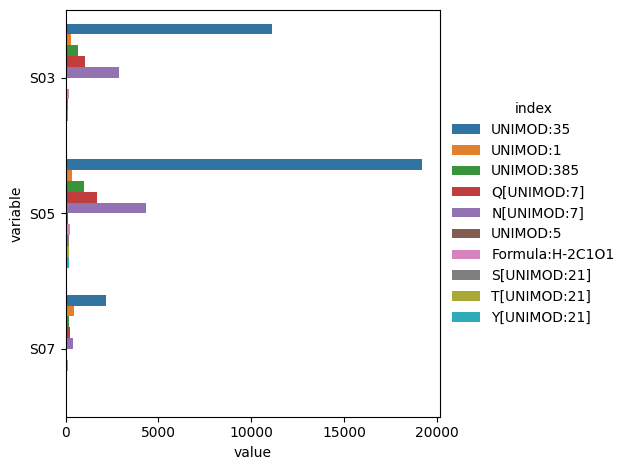

In [8]:
ax = sns.barplot(
    data=modified_spectra_counts,
    y='variable',
    x='value',
    hue='index'
)

sns.move_legend(
    ax,
    loc='center left',
    bbox_to_anchor=(1, 0.5),  # outside right
    frameon=False
)

plt.tight_layout()

In [9]:
runs

{'S03': S03 (152420 spectra),
 'S05': S05 (232746 spectra),
 'S07': S07 (46812 spectra)}

In [10]:
denovo_modification_filter_map = {
    'AdaNovo': [
        'UNIMOD:385',
        'UNIMOD:5',
        'Formula:H-2C1O1',
        'S[UNIMOD:21]',
        'T[UNIMOD:21]',
        'Y[UNIMOD:21]'
    ],
    'pi-PrimeNovo': [
        'S[UNIMOD:21]',
        'T[UNIMOD:21]',
        'Y[UNIMOD:21]'
    ],
    'pi-HelixNovo': [
        'S[UNIMOD:21]',
        'T[UNIMOD:21]',
        'Y[UNIMOD:21]'
    ],
    'Casanovo4.2.0': [
        'S[UNIMOD:21]',
        'T[UNIMOD:21]',
        'Y[UNIMOD:21]'
    ],
    'InstaNovo-v1.1': [
        'Formula:H-2C1O1',
        
    ],
    'ContraNovo': [
        'S[UNIMOD:21]',
        'T[UNIMOD:21]',
        'Y[UNIMOD:21]'
    ],
    'NovoB': [
        'UNIMOD:1',
        'UNIMOD:385',
        'UNIMOD:5',
        'Formula:H-2C1O1',
    ],
    'PepNet': [
        'UNIMOD:35',
        'UNIMOD:1',
        'UNIMOD:385',
        'UNIMOD:5',
        'Formula:H-2C1O1',
        'S[UNIMOD:21]',
        'T[UNIMOD:21]',
        'Y[UNIMOD:21]',
        'Q[UNIMOD:7]',
        'N[UNIMOD:7]'
    ]
}

In [11]:
removed = {denovo_name: 0 for denovo_name in denovo_names}
for run_name, mod_dict in modifications_per_run.items():
    for mod_name, speclist in mod_dict.items():
        for spectrum_id in speclist:
            new_candidate_list = []
            spectrum = runs[run_name].get_spectrum(spectrum_id)
            for candidate in spectrum.psm_candidates:
                # If the spectrum has a gold standard modification not supproted
                # by de novo model, remove
                if mod_name in denovo_modification_filter_map[candidate.engine_name]:
                    removed[candidate.engine_name] += 1
                    continue
                else:
                    new_candidate_list.append(candidate)
            spectrum.psm_candidates = new_candidate_list

In [12]:
removed

{'AdaNovo': 3239,
 'Casanovo4.2.0': 892,
 'ContraNovo': 471,
 'InstaNovo-v1.1': 514,
 'NovoB': 3445,
 'PepNet': 44202,
 'pi-HelixNovo': 909,
 'pi-PrimeNovo': 916}

## 2. Create PR tables

In [13]:
# Perform error type analysis
for run in runs.values():
    for spectrum in tqdm(run.spectra.values()):
        spectrum.compare_gold_standard(
            metadata_score='score_ms2rescore',
            ignore_score=True
        )

100%|██████████| 46812/46812 [00:44<00:00, 1058.08it/s] 


In [14]:
pr_tables_all_spectra = get_match_score_tables(runs=runs, denovo_names=denovo_names, match_type_from_metadata=False)

In [15]:
for denovo_name, table in pr_tables_all_spectra.items():
    print(denovo_name, table.shape)

AdaNovo (387053, 3)
Casanovo4.2.0 (387655, 3)
ContraNovo (196229, 3)
InstaNovo-v1.1 (391838, 3)
NovoB (372399, 3)
PepNet (387683, 3)
pi-HelixNovo (393299, 3)
pi-PrimeNovo (399471, 3)


In [16]:
pr_dict = get_pr_rec_cov_dict(runs=runs, pr_tables=pr_tables_all_spectra)

100%|██████████| 200/200 [00:01<00:00, 104.38it/s]


In [18]:
source_data_fig1C = pd.DataFrame(pr_dict).T

cols = ["precision", "recall", "coverage"]

long = (source_data_fig1C.rename_axis("model")
          .reset_index()
          .explode(cols, ignore_index=True))
long[cols] = long[cols].astype(float)
long.insert(1, "point", long.groupby("model").cumcount())


with pd.ExcelWriter('source_data/Source_Data_Figure1.xlsx', engine='openpyxl',
                    mode='a', if_sheet_exists='replace') as xl:
    long.to_excel(xl, sheet_name='C', index=False)

plotting AdaNovo
plotting Casanovo4.2.0
plotting ContraNovo
plotting InstaNovo-v1.1
plotting NovoB
plotting PepNet
plotting pi-HelixNovo
plotting pi-PrimeNovo


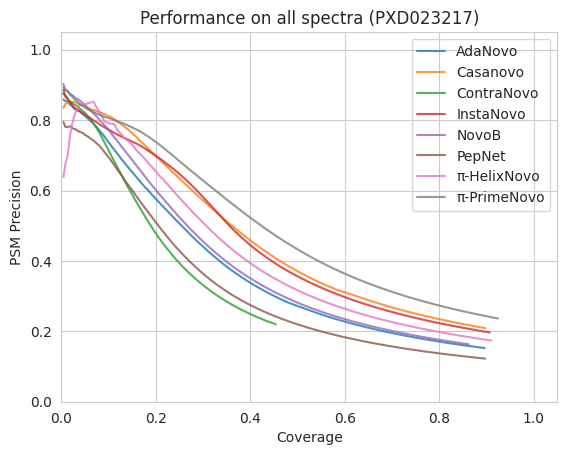

In [27]:
plt.figure(facecolor='none')  # or 'transparent'
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True

# plotting a precision coverage curve
denovo_labels = {
    'PepNet': 'PepNet',
    'NovoB': 'NovoB',
    'InstaNovo-v1.1': 'InstaNovo',
    'Casanovo4.2.0': 'Casanovo',
    'ContraNovo': 'ContraNovo',
    'AdaNovo': 'AdaNovo',
    'pi-PrimeNovo': 'π-PrimeNovo',
    'pi-HelixNovo': 'π-HelixNovo'
}
for denovo_name in denovo_names:
    pr_dict_ = pr_dict[denovo_name]
    print("plotting", denovo_name)
    sns.lineplot(
        x=pr_dict_["coverage"],
        y=pr_dict_["precision"],
        label=denovo_labels[denovo_name],   # Label for style legend
        alpha=.8,
    )

plt.xlim((0,1.05))
plt.ylim((0,1.05))
plt.title("Performance on all spectra (PXD023217)")
plt.xlabel('Coverage')
plt.ylabel('PSM Precision')
plt.show("F1C_PCMetaprot")

plotting AdaNovo
plotting Casanovo4.2.0
plotting ContraNovo
plotting InstaNovo
plotting NovoB
plotting PepNet
plotting pi-HelixNovo
plotting pi-PrimeNovo


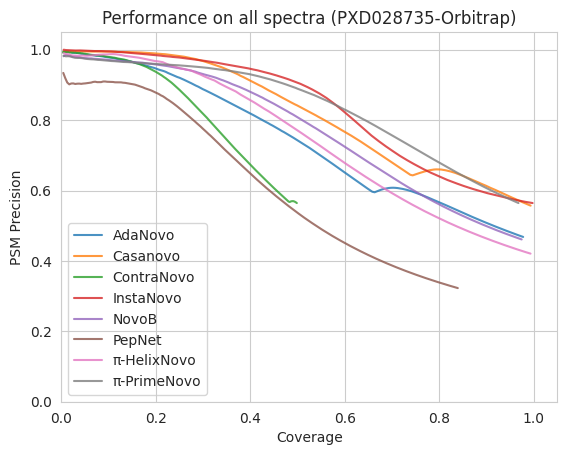

In [144]:
plt.figure(facecolor='none')  # or 'transparent'
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True

# plotting a precision coverage curve
denovo_labels = {
    'PepNet': 'PepNet',
    'NovoB': 'NovoB',
    'InstaNovo': 'InstaNovo',
    'Casanovo4.2.0': 'Casanovo',
    'ContraNovo': 'ContraNovo',
    'AdaNovo': 'AdaNovo',
    'pi-PrimeNovo': 'π-PrimeNovo',
    'pi-HelixNovo': 'π-HelixNovo'
}
for denovo_name in denovo_names:
    pr_dict_ = pr_dict_fasta[denovo_name]
    print("plotting", denovo_name)
    sns.lineplot(
        x=pr_dict_["coverage"],
        y=pr_dict_["precision"],
        label=denovo_labels[denovo_name],   # Label for style legend
        alpha=.8,
    )

plt.xlim((0,1.05))
plt.ylim((0,1.05))
plt.title("Performance on all spectra (PXD028735-Orbitrap)")
plt.xlabel('Coverage')
plt.ylabel('PSM Precision')
plt.show()

In [147]:
with open('runs_PXD028735_QExactive_modcleanup.pkl', 'wb') as f:
    pickle.dump(runs, f)

## 3. Attribution of correct predictions to each search engine and rank

### 3.1. Search engine

In [ ]:
runs['LFQ_Orbitrap_DDA_Ecoli_01'].spectra['controllerType=0 controllerNumber=1 scan=10393'].psm_candidates[
    0
].evaluations

In [162]:
runs['LFQ_Orbitrap_DDA_Ecoli_01'].spectra['controllerType=0 controllerNumber=1 scan=10005'].psm_gold_standard[0].rank

1

In [158]:
denovo_names

['AdaNovo',
 'Casanovo4.2.0',
 'ContraNovo',
 'InstaNovo',
 'NovoB',
 'PepNet',
 'pi-HelixNovo',
 'pi-PrimeNovo']

In [180]:
rank_attribution = {denovo_name: {} for denovo_name in denovo_names}
SE_attribution = {denovo_name: {} for denovo_name in denovo_names}
correctness = {denovo_name: {} for denovo_name in denovo_names}

def get_gs_by_rank(psms, rank):
    for psm in psms:
        if psm.rank == rank:
            return psm.engine_name
    raise Exception('Gold standard not found.')

for run_name, run in runs.items():
    for spectrum in tqdm(run.spectra.values()):
        for candidate in spectrum.psm_candidates:
            if candidate.metadata['match_type'] in correctness[candidate.engine_name].keys():
                correctness[candidate.engine_name][candidate.metadata['match_type']] += 1
            else:
                correctness[candidate.engine_name][candidate.metadata['match_type']] = 1

            for rank, eval in candidate.evaluations.items():
                if eval['score_ms2rescore'].error_type=='match':
                    source = get_gs_by_rank(spectrum.psm_gold_standard, rank)

                    if rank in rank_attribution[candidate.engine_name].keys():
                        rank_attribution[candidate.engine_name][rank] += 1
                    else:
                        rank_attribution[candidate.engine_name][rank] = 1

                    if source in SE_attribution[candidate.engine_name].keys():
                        SE_attribution[candidate.engine_name][source] += 1
                    else:
                        SE_attribution[candidate.engine_name][source] = 1

100%|██████████| 49588/49588 [00:00<00:00, 64654.85it/s]


In [183]:
SE_attribution_df = pd.DataFrame(SE_attribution)
rank_attribution_df = pd.DataFrame(rank_attribution)
correctness_df = pd.DataFrame(correctness)

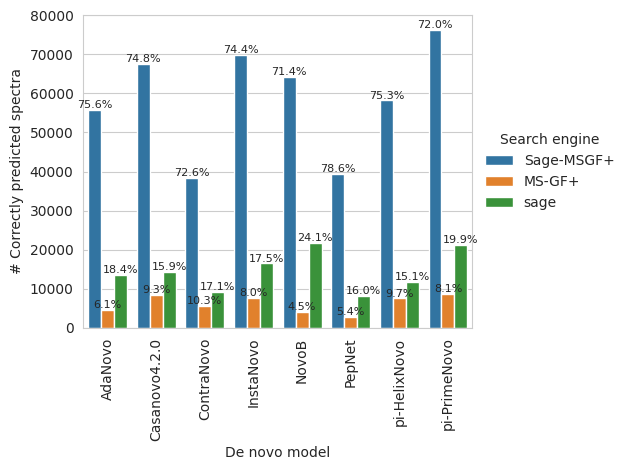

In [179]:
import numpy as np
import pandas as pd

# Prepare data
df_long = SE_attribution_df.reset_index().melt(id_vars='index')

ax = sns.barplot(
    data=df_long,
    x='variable',
    y='value',
    hue='index'
)

# Rotate x ticks
ax.tick_params(axis='x', rotation=90)

# Rename axes
ax.set_xlabel('De novo model')
ax.set_ylabel('# Correctly predicted spectra')

# Move legend outside
sns.move_legend(
    ax,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    title='Search engine'
)

# ---- Compute totals per model ----
totals = df_long.groupby('variable')['value'].sum()

# ---- Annotate every bar ----
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        x_center = bar.get_x() + bar.get_width() / 2
        
        # Determine which model this bar belongs to
        model_index = int(round(x_center))
        model = totals.index[model_index]
        total = totals[model]
        
        pct = height / total * 100
        
        ax.annotate(
            f"{pct:.1f}%",
            (x_center, height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()

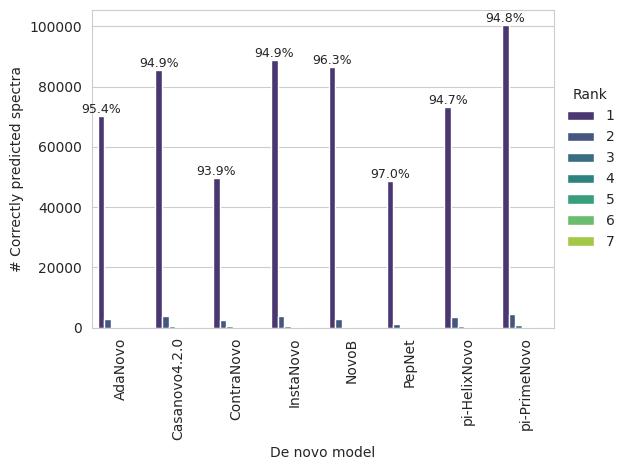

In [178]:
import numpy as np

# Ensure ranks are sorted numerically (important!)
rank_attribution_df = rank_attribution_df.sort_index()

n_ranks = rank_attribution_df.index.nunique()
palette = sns.color_palette("viridis", n_colors=n_ranks)

ax = sns.barplot(
    data=rank_attribution_df.reset_index().melt(id_vars='index'),
    x='variable',
    y='value',
    hue='index',
    palette=palette
)

# Rotate x ticks
ax.tick_params(axis='x', rotation=90)

# Rename axes
ax.set_xlabel('De novo model')
ax.set_ylabel('# Correctly predicted spectra')

# Rename + move legend
sns.move_legend(
    ax,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    title='Rank'
)

# ---- Add percentages for Rank 1 only ----

# Get total per x-category (sum over all ranks)
grouped = (
    rank_attribution_df
    .reset_index()
    .melt(id_vars='index')
    .groupby('variable')['value']
    .sum()
)

# Rank 1 container is first if sorted
rank1_container = ax.containers[0]

for bar, model in zip(rank1_container, grouped.index):
    height = bar.get_height()
    total = grouped[model]
    pct = height / total * 100
    
    ax.annotate(
        f"{pct:.1f}%",
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()

error types

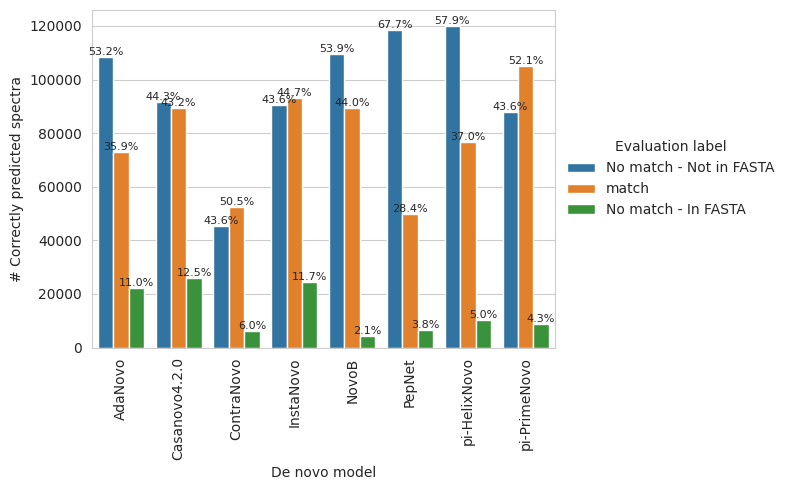

In [187]:
import numpy as np
import pandas as pd

# Prepare data
df_long = correctness_df.reset_index().melt(id_vars='index')

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=df_long,
    x='variable',
    y='value',
    hue='index'
)

# Rotate x ticks
ax.tick_params(axis='x', rotation=90)

# Rename axes
ax.set_xlabel('De novo model')
ax.set_ylabel('# Correctly predicted spectra')

# Move legend outside
sns.move_legend(
    ax,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    title='Evaluation label'
)

# ---- Compute totals per model ----
totals = df_long.groupby('variable')['value'].sum()

# ---- Annotate every bar ----
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        x_center = bar.get_x() + bar.get_width() / 2
        
        # Determine which model this bar belongs to
        model_index = int(round(x_center))
        model = totals.index[model_index]
        total = totals[model]
        
        pct = height / total * 100
        
        ax.annotate(
            f"{pct:.1f}%",
            (x_center, height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()

---

# TimsTOF